# Retail Analytics Pipeline — Módulo 9
## Lección 3: Transformaciones RDD — `map`, `filter`, `flatMap`, `distinct`, `sortBy`, Pair RDDs, `reduceByKey`, Acciones, DAG y `cache`

**Empresa ficticia:** RetailMax (e-commerce de moda)  
**Dataset:** Fashion-MNIST — estadísticas precalculadas (sin array de píxeles)  
**Entorno:** VS Code Windows · `.venv_spark` · Python 3.10 · PySpark  

---

> **RESTRICCIÓN CRÍTICA:** El RDD base **NO** contiene la clave `"pixels"`.  
> Cada registro tiene exactamente: `image_id`, `label`, `label_name`, `split`,  
> `pixel_mean`, `pixel_std`, `pixel_max`, `pixel_min`.  
> **Jamás** usar `r["pixels"]` en ninguna celda.

---

### Índice
| Sección | Tema |
|---------|------|
| 0 | Configuración inicial y carga de datos |
| 1 | Transformación `map` (3 pasos) |
| 2 | Transformación `filter` (3 pasos) |
| 3 | Transformación `flatMap` (3 pasos) |
| 4 | `distinct` y `sortBy` + bar chart |
| 5 | Pair RDDs y `reduceByKey` |
| 6 | Acciones: `count`, `sum`, `mean`, `stdev` |
| 7 | DAG y linaje |
| 8 | `cache()` y persistencia |
| 9 | Guardar a disco con `saveAsTextFile` |
| 10 | Cierre Spark e Informe final |


---
## Sección 0 — Configuración inicial y carga de datos

### Concepto
Antes de cualquier operación Spark debemos:
1. Configurar variables de entorno de Hadoop (Windows).
2. Crear la `SparkSession` (punto de entrada unificado desde Spark 2.x).
3. Cargar Fashion-MNIST y construir registros **sin** el array de píxeles.

```
SparkSession
    └── SparkContext (sc)  ← API de bajo nivel para RDDs
            └── RDD base  ← datos distribuidos
```

In [32]:
# ─── Paso 0.1 — Importaciones y variables de entorno de Hadoop ───────────
import os, sys, time
import numpy as np

# HADOOP_HOME debe configurarse ANTES de importar pyspark
os.environ["HADOOP_HOME"]     = r"D:\hadoop"         # ruta de winutils.exe
os.environ["hadoop.home.dir"] = r"D:\hadoop"         # alias requerido por Spark
os.environ["PATH"]            = r"D:\hadoop\bin;" + os.environ.get("PATH", "")

print("Variables de entorno Hadoop configuradas")
print(f"  HADOOP_HOME = {os.environ['HADOOP_HOME']}")


Variables de entorno Hadoop configuradas
  HADOOP_HOME = D:\hadoop


In [33]:
# ─── Paso 0.2 — Crear SparkSession ─────────────────────────────────────────
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .master("local[*]")                               # usar todos los núcleos locales
         .appName("RetailMax_L3_RDDs")                     # nombre en la Spark UI
         .config("spark.driver.memory", "4g")              # memoria del driver
         .config("spark.sql.shuffle.partitions", "4")      # particiones para shuffles
         .config("spark.ui.showConsoleProgress", "false")  # silenciar barra de progreso
         .getOrCreate())                                   # reutilizar sesión si existe

sc = spark.sparkContext    # SparkContext: API de RDDs de bajo nivel
sc.setLogLevel("ERROR")    # sólo errores, no warnings ni INFO

print("SparkSession creada correctamente")
print(f"  Versión Spark : {spark.version}")
print(f"  App ID        : {sc.applicationId}")


SparkSession creada correctamente
  Versión Spark : 4.1.1
  App ID        : local-1774400022040


In [34]:
# ─── Paso 0.3 — Diccionario de etiquetas Fashion-MNIST ─────────────────────
label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}
print(f" {len(label_names)} clases de ropa registradas:")
for k, v in label_names.items():
    print(f"  {k}: {v}")


 10 clases de ropa registradas:
  0: T-shirt/top
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot


In [35]:
# ─── Paso 0.4 — Carga de Fashion-MNIST con fallback en cadena ───────────────
#    Orden de intentos: TensorFlow → PyTorch → scikit-learn → datos sintéticos

X_train = X_test = y_train = y_test = None    # inicializar como None

# Intento 1: TensorFlow / Keras
try:
    import tensorflow as tf
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    print(" Datos cargados con TensorFlow/Keras")
except Exception as e_tf:
    print(f"  TensorFlow no disponible: {e_tf}")

    # Intento 2: PyTorch + torchvision
    try:
        import torchvision, torch
        ds_train = torchvision.datasets.FashionMNIST(
            root="./data", train=True,  download=True)
        ds_test  = torchvision.datasets.FashionMNIST(
            root="./data", train=False, download=True)
        X_train = ds_train.data.numpy()      # tensor → numpy array
        y_train = ds_train.targets.numpy()
        X_test  = ds_test.data.numpy()
        y_test  = ds_test.targets.numpy()
        print(" Datos cargados con PyTorch/torchvision")
    except Exception as e_pt:
        print(f"  PyTorch no disponible: {e_pt}")

        # Intento 3: scikit-learn (OpenML)
        try:
            from sklearn.datasets import fetch_openml
            fmnist = fetch_openml("Fashion-MNIST", version=1,
                                  as_frame=False, parser="auto")
            X_all  = fmnist.data.reshape(-1, 28, 28).astype(np.uint8)
            y_all  = fmnist.target.astype(int)
            X_train, y_train = X_all[:60000], y_all[:60000]
            X_test,  y_test  = X_all[60000:], y_all[60000:]
            print(" Datos cargados con scikit-learn / OpenML")
        except Exception as e_sk:
            print(f"  scikit-learn no disponible: {e_sk}")

            # Fallback final: datos sintéticos reproducibles
            print(" Usando datos SINTÉTICOS (ninguna biblioteca ML disponible)")
            rng = np.random.default_rng(seed=42)           # semilla fija
            X_train = rng.integers(0, 256, (60000, 28, 28), dtype=np.uint8)
            y_train = rng.integers(0, 10, 60000, dtype=np.uint8)
            X_test  = rng.integers(0, 256, (10000, 28, 28), dtype=np.uint8)
            y_test  = rng.integers(0, 10, 10000, dtype=np.uint8)

print(f"  X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"  X_test  shape: {X_test.shape}   |  y_test  shape: {y_test.shape}")


 Datos cargados con TensorFlow/Keras
  X_train shape: (60000, 28, 28)  |  y_train shape: (60000,)
  X_test  shape: (10000, 28, 28)   |  y_test  shape: (10000,)


In [36]:
# ─── Paso 0.5 — Normalizar píxeles al rango [0, 1] ─────────────────────────
#    Las imágenes crudas tienen valores uint8 en [0, 255]

if X_train.max() > 1.0:                              # verificar si ya está normalizado
    X_train = X_train.astype(np.float32) / 255.0     # 0-255 → 0.0-1.0
    X_test  = X_test.astype(np.float32)  / 255.0     # ídem para test
    print(" Píxeles normalizados a [0, 1]")

print(f"  X_train rango: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"  X_test  rango: [{X_test.min():.2f},  {X_test.max():.2f}]")


 Píxeles normalizados a [0, 1]
  X_train rango: [0.00, 1.00]
  X_test  rango: [0.00,  1.00]


In [37]:
# ─── Paso 0.6 — Función para construir registros SIN columna 'pixels' ───────
#    Cada imagen → 1 diccionario con 8 campos (estadísticas agregadas)
#    NUNCA se almacena el array completo de 784 píxeles en el RDD

def construir_registro(i, X, y, split):
    """
    Convierte la imagen i en un dict con estadísticas precalculadas.
    No incluye el array de píxeles para mantener el RDD ligero.

    Parámetros:
        i     : índice de la imagen
        X     : array de imágenes (N, 28, 28) float32
        y     : array de etiquetas (N,) int
        split : 'train' o 'test'
    Retorna:
        dict con 8 claves: image_id, label, label_name, split,
                           pixel_mean, pixel_std, pixel_max, pixel_min
    """
    px = X[i]                                          # array 2D (28,28) de float32
    return {
        "image_id":   int(i) if split == "train" else int(60000 + i),
        "label":      int(y[i]),
        "label_name": label_names[int(y[i])],         # nombre legible de la clase
        "split":      split,                          # 'train' o 'test'
        "pixel_mean": float(np.mean(px)),             # brillo promedio
        "pixel_std":  float(np.std(px)),              # varianza del brillo
        "pixel_max":  float(np.max(px)),              # píxel más brillante
        "pixel_min":  float(np.min(px)),              # píxel más oscuro
    }

print("Función construir_registro definida")
print("  Campos del registro: image_id | label | label_name | split")
print("                       pixel_mean | pixel_std | pixel_max | pixel_min")
print("NO se almacena el array de píxeles (r['pixels'] no existe)")


Función construir_registro definida
  Campos del registro: image_id | label | label_name | split
                       pixel_mean | pixel_std | pixel_max | pixel_min
NO se almacena el array de píxeles (r['pixels'] no existe)


In [38]:
# ─── Paso 0.7 — Construir lista de registros y paralelizar en RDD ───────────

N_TRAIN, N_TEST = 10_000, 2_000    # usar subconjunto para agilizar en entorno local

# Construir lista plana de registros (train primero, luego test)
data = (
    [construir_registro(i, X_train, y_train, "train") for i in range(N_TRAIN)] +
    [construir_registro(i, X_test,  y_test,  "test")  for i in range(N_TEST)]
)

# Paralelizar: distribuir la lista en 4 particiones del clúster local
rdd_base = sc.parallelize(data, numSlices=4)
#              ↑ numSlices=4 → 4 particiones → 4 tasks en local[*]

print(f"  RDD base creado")
print(f"  Total registros   : {rdd_base.count()}")
print(f"  Particiones       : {rdd_base.getNumPartitions()}")
print(f"  Primer registro   : ")
primer = rdd_base.first()
for k, v in primer.items():
    print(f"    {k:<12}: {v}")


  RDD base creado
  Total registros   : 12000
  Particiones       : 4
  Primer registro   : 
    image_id    : 0
    label       : 9
    label_name  : Ankle boot
    split       : train
    pixel_mean  : 0.3813875615596771
    pixel_std   : 0.3991856873035431
    pixel_max   : 1.0
    pixel_min   : 0.0


---
## Sección 1 — Transformación `map`

### Concepto
`map(f)` aplica la función `f` a **cada elemento** del RDD.  
Produce exactamente el mismo número de elementos de salida que de entrada (**1 → 1**).

```
RDD entrada:  [r1,  r2,  r3,  ...]
                ↓    ↓    ↓
RDD salida:  [f(r1),f(r2),f(r3),...]
```

> Es una transformación **lazy** (no se ejecuta hasta que se llama una acción)  
> y **narrow** (no requiere shuffle de datos entre particiones).


In [39]:
# ─── Paso 1.1 — Extraer sólo metadatos de identificación ───────────────────
# Resultado: RDD de tuplas (image_id, label, label_name, split)
# Reduce el tamaño del RDD de 8 campos a 4 campos esenciales

rdd_metadata = rdd_base.map(
    lambda r: (r["image_id"], r["label"], r["label_name"], r["split"])
    # ↑ CORRECTO: accedemos sólo a campos existentes
    # ✗ PROHIBIDO: r["pixels"] NO EXISTE en este RDD
)

print("[1.1] Primeros 3 registros de metadatos (image_id, label, label_name, split):")
for rec in rdd_metadata.take(3):
    print(f"  {rec}")

print(f"\n  Total registros (mismo que rdd_base): {rdd_metadata.count()}")


[1.1] Primeros 3 registros de metadatos (image_id, label, label_name, split):
  (0, 9, 'Ankle boot', 'train')
  (1, 0, 'T-shirt/top', 'train')
  (2, 0, 'T-shirt/top', 'train')

  Total registros (mismo que rdd_base): 12000


In [40]:
# ─── Paso 1.2 — Calcular brightness_score ───────────────────────────────────
# Fórmula: brightness_score = (pixel_mean + pixel_max) / 2
# Representa el brillo general de la imagen en RetailMax
# Usa {**r} para conservar todos los campos originales y añadir uno nuevo

rdd_brightness = rdd_base.map(
    lambda r: {
        **r,                                                      # todos los campos originales
        "brightness_score": round((r["pixel_mean"] + r["pixel_max"]) / 2, 6)
        #                           ↑ pixel_mean: brillo promedio de todos los píxeles
        #                                          ↑ pixel_max: valor del píxel más brillante
        # NO usar r["pixels"] — ese campo no existe en este RDD
    }
)

print("[1.2] Brightness score — primeros 2 registros (campos relevantes):")
print(f"  {'image_id':>8} {'label_name':<14} {'pixel_mean':>10} {'pixel_max':>10} {'brightness':>12}")
print(f"  {'-'*60}")
for rec in rdd_brightness.take(2):
    print(f"  {rec['image_id']:>8} {rec['label_name']:<14} "
          f"{rec['pixel_mean']:>10.4f} {rec['pixel_max']:>10.4f} "
          f"{rec['brightness_score']:>12.6f}")


[1.2] Brightness score — primeros 2 registros (campos relevantes):
  image_id label_name     pixel_mean  pixel_max   brightness
  ------------------------------------------------------------
         0 Ankle boot         0.3814     1.0000     0.690694
         1 T-shirt/top        0.4232     1.0000     0.711580


In [41]:
# ─── Paso 1.3 — Normalización de estadísticas de [0,1] a [-1,1] ─────────────
# Fórmula: valor_norm = valor * 2 - 1
# Esta transformación afín mapea [0,1] → [-1,1]
# Es estándar en redes neuronales (centrar datos alrededor de 0)

print("[1.3] Mini-ejemplo de normalización [0,1] → [-1,1]:")
print(f"  {'Valor orig':>10}  →  {'Valor norm':>10}  (fórmula: x*2 - 1)")
print(f"  {'-'*38}")
for v in [0.0, 0.3, 0.5, 0.8, 1.0]:
    print(f"  {v:>10.1f}  →  {v*2-1:>10.2f}")

# Aplicar normalización al RDD
rdd_normalized = rdd_base.map(
    lambda r: {
        **r,                                                           # campos originales
        "pixel_mean_norm": round(r["pixel_mean"] * 2 - 1, 4),          # media normalizada
        "pixel_std_norm":  round(r["pixel_std"]  * 2 - 1, 4),          # desv.est. normalizada
        # NUNCA: r["pixels"] * 2 - 1  — r["pixels"] NO EXISTE
    }
)

print("\nTabla comparativa — primeros 3 registros:")
print(f"  {'label_name':<14} {'pixel_mean_orig':>16} {'pixel_mean_norm':>16}")
print(f"  {'-'*50}")
for rec in rdd_normalized.take(3):
    print(f"  {rec['label_name']:<14} {rec['pixel_mean']:>16.4f} {rec['pixel_mean_norm']:>16.4f}")


[1.3] Mini-ejemplo de normalización [0,1] → [-1,1]:
  Valor orig  →  Valor norm  (fórmula: x*2 - 1)
  --------------------------------------
         0.0  →       -1.00
         0.3  →       -0.40
         0.5  →        0.00
         0.8  →        0.60
         1.0  →        1.00

Tabla comparativa — primeros 3 registros:
  label_name      pixel_mean_orig  pixel_mean_norm
  --------------------------------------------------
  Ankle boot               0.3814          -0.2372
  T-shirt/top              0.4232          -0.1537
  T-shirt/top              0.1434          -0.7133


---
## Sección 2 — Transformación `filter`

### Concepto
`filter(f)` devuelve un nuevo RDD con sólo los elementos donde `f(x)` es `True`.  
El número de elementos de salida es **menor o igual** al de entrada (**1 → 0 ó 1**).

```
RDD entrada:  [r1,  r2,  r3,  r4,  r5]
               ✓    ✗    ✓    ✓    ✗
RDD salida:   [r1,       r3,  r4     ]
```

> Es también **lazy** y **narrow** — cada partición filtra de forma independiente.


In [42]:
# ─── Paso 2.0 — Total de registros (referencia para porcentajes) ─────────────
total = rdd_base.count()    # acción: cuenta todos los registros
print(f"Total de registros en rdd_base: {total}")


Total de registros en rdd_base: 12000


In [43]:
# ─── Paso 2.1 — Filtrar sólo imágenes de clase Bag (label == 8) ─────────────
# Caso de uso RetailMax: analizar exclusivamente el catálogo de bolsos

rdd_bags = rdd_base.filter(
    lambda r: r["label"] == 8    # label 8 = "Bag" según label_names
    # Campo correcto: r["label"] (int) — NO usar r["pixels"]
)

n_bags = rdd_bags.count()    # acción: cuenta los Bags
print(f"[2.1] Imágenes de Bag (label=8):")
print(f"  Cantidad  : {n_bags}")
print(f"  Porcentaje: {n_bags/total*100:.2f}% del total ({total} registros)")
print(f"  Primer registro filtrado:")
primer_bag = rdd_bags.first()
for k, v in primer_bag.items():
    print(f"    {k:<12}: {v}")


[2.1] Imágenes de Bag (label=8):
  Cantidad  : 1184
  Porcentaje: 9.87% del total (12000 registros)
  Primer registro filtrado:
    image_id    : 23
    label       : 8
    label_name  : Bag
    split       : train
    pixel_mean  : 0.3910514712333679
    pixel_std   : 0.2865382134914398
    pixel_max   : 1.0
    pixel_min   : 0.0


In [44]:
# ─── Paso 2.2 — Filtrar imágenes brillantes (pixel_mean > 0.5) ───────────────
# Caso de uso: detectar imágenes claras (fondo blanco o prendas de color claro)
# pixel_mean es el promedio de todos los píxeles normalizados de la imagen

rdd_bright = rdd_base.filter(
    lambda r: r["pixel_mean"] > 0.5    # pixel_mean > 0.5 → imagen relativamente brillante
    # Accedemos a pixel_mean (campo precalculado) — NUNCA a r["pixels"]
)

n_bright = rdd_bright.count()
print(f"[2.2] Imágenes con pixel_mean > 0.5 (imágenes brillantes):")
print(f"  Cantidad  : {n_bright}")
print(f"  Porcentaje: {n_bright/total*100:.2f}% del total ({total} registros)")
print(f"  Interpretación: el {n_bright/total*100:.1f}% del catálogo RetailMax ")
print(f"  tiene imágenes con brillo promedio > 50% (fondos claros o prendas claras)")


[2.2] Imágenes con pixel_mean > 0.5 (imágenes brillantes):
  Cantidad  : 641
  Porcentaje: 5.34% del total (12000 registros)
  Interpretación: el 5.3% del catálogo RetailMax 
  tiene imágenes con brillo promedio > 50% (fondos claros o prendas claras)


In [45]:
# ─── Paso 2.3 — Filtrar sólo el split de test ────────────────────────────────
# Caso de uso: evaluar métricas sólo sobre datos no vistos durante el entrenamiento

rdd_test_split = rdd_base.filter(
    lambda r: r["split"] == "test"    # split = 'test' → imágenes de evaluación
)

n_test_split = rdd_test_split.count()
print(f"[2.3] Imágenes del split 'test':")
print(f"  Cantidad  : {n_test_split}")
print(f"  Porcentaje: {n_test_split/total*100:.2f}% del total")

# Verificar split 'train' con operador negado
n_train_split = rdd_base.filter(lambda r: r["split"] == "train").count()
print(f"\n  Distribución del dataset:")
print(f"    train: {n_train_split} ({n_train_split/total*100:.1f}%)")
print(f"    test : {n_test_split} ({n_test_split/total*100:.1f}%)")


[2.3] Imágenes del split 'test':
  Cantidad  : 2000
  Porcentaje: 16.67% del total

  Distribución del dataset:
    train: 10000 (83.3%)
    test : 2000 (16.7%)


---
## Sección 3 — Transformación `flatMap`

### Concepto
`flatMap(f)` aplica `f` a cada elemento produciendo **una lista**, luego aplana todas las listas.
A diferencia de `map`, cada elemento de entrada puede generar **0, 1 ó N** elementos de salida.

```
map     → [f(r1),          f(r2),       f(r3)      ]   # 3 entradas → 3 salidas
flatMap → [f1(r1),f2(r1), f1(r2),       f2(r2), ...]   # 3 entradas → 3*N salidas
```

**Caso de uso RetailMax:** cada imagen genera 4 filas, una por estadística de píxel,  
para facilitar consultas tipo `GROUP BY estadística`.

> **Recordatorio crítico:** las estadísticas son `pixel_mean`, `pixel_std`, `pixel_max`, `pixel_min`.  
> En ningún caso usamos `r["pixels"]`.


In [46]:
# ─── Paso 3.1 — flatMap: 1 imagen → 4 tuplas (una por estadística) ──────────
# Cada registro del RDD produce una lista de 4 tuplas:
#   (image_id, label_name, nombre_estadistica, valor)

rdd_pixels_flat = rdd_base.flatMap(
    lambda r: [
        # Tupla: (image_id, label_name, stat_name, valor)
        (r["image_id"], r["label_name"], "pixel_mean", r["pixel_mean"]),
        (r["image_id"], r["label_name"], "pixel_std",  r["pixel_std"]),
        (r["image_id"], r["label_name"], "pixel_max",  r["pixel_max"]),
        (r["image_id"], r["label_name"], "pixel_min",  r["pixel_min"]),
        # ↑ NUNCA usar r["pixels"] — usamos sólo los 4 campos precalculados
    ]
)

print("[3.1] rdd_pixels_flat creado (lazy — aún no ejecutado)")
print(f"  Transformación: 1 imagen → 4 tuplas (una por estadística)")


[3.1] rdd_pixels_flat creado (lazy — aún no ejecutado)
  Transformación: 1 imagen → 4 tuplas (una por estadística)


In [47]:
# ─── Paso 3.2 — Verificar el factor de expansión 4x ─────────────────────────

count_original = rdd_base.count()           # número de imágenes (acción)
count_flat     = rdd_pixels_flat.count()    # número de tuplas estadísticas (acción)

print(f"[3.2] Factor de expansión flatMap:")
print(f"  Registros originales  (rdd_base)        : {count_original}")
print(f"  Registros tras flatMap (rdd_pixels_flat): {count_flat}")
print(f"  Factor de expansión                     : {count_flat // count_original}x")
print(f"  Esperado                                : 4x ({'correcto' if count_flat // count_original == 4 else 'revisar'})")


[3.2] Factor de expansión flatMap:
  Registros originales  (rdd_base)        : 12000
  Registros tras flatMap (rdd_pixels_flat): 48000
  Factor de expansión                     : 4x
  Esperado                                : 4x (correcto)


In [48]:
# ─── Paso 3.3 — Mostrar primeras 8 tuplas (2 imágenes × 4 estadísticas) ─────

print(f"[3.3] Primeras 8 tuplas del RDD aplanado (= 2 imágenes completas):")
print(f"  {'image_id':>10} {'label_name':<14} {'estadística':<12} {'valor':>10}")
print(f"  {'-'*52}")
for tup in rdd_pixels_flat.take(8):
    print(f"  {tup[0]:>10} {tup[1]:<14} {tup[2]:<12} {tup[3]:>10.6f}")

print("\n[3.3] Diferencia map vs flatMap:")
print("  map    → transforma, preserva estructura (1 entrada → 1 salida)")
print("  flatMap→ transforma Y aplana (1 entrada → N salidas concatenadas)")
print("  Análogía SQL: flatMap ≈ LATERAL JOIN / UNNEST")
print("  Uso RetailMax: analizar cada estadística por separado, agrupar por 'pixel_max', etc.")


[3.3] Primeras 8 tuplas del RDD aplanado (= 2 imágenes completas):
    image_id label_name     estadística       valor
  ----------------------------------------------------
           0 Ankle boot     pixel_mean     0.381388
           0 Ankle boot     pixel_std      0.399186
           0 Ankle boot     pixel_max      1.000000
           0 Ankle boot     pixel_min      0.000000
           1 T-shirt/top    pixel_mean     0.423159
           1 T-shirt/top    pixel_std      0.395417
           1 T-shirt/top    pixel_max      1.000000
           1 T-shirt/top    pixel_min      0.000000

[3.3] Diferencia map vs flatMap:
  map    → transforma, preserva estructura (1 entrada → 1 salida)
  flatMap→ transforma Y aplana (1 entrada → N salidas concatenadas)
  Análogía SQL: flatMap ≈ LATERAL JOIN / UNNEST
  Uso RetailMax: analizar cada estadística por separado, agrupar por 'pixel_max', etc.


---
## Sección 4 — `distinct` y `sortBy` + Visualización

### Conceptos
- **`distinct()`**: elimina elementos duplicados. Requiere shuffle (**wide** transformation).
- **`sortBy(f, ascending)`**: ordena el RDD completo según la clave `f`. También **wide**.

> Ambas operaciones requieren comunicación entre particiones (shuffle),  
> por lo que son más costosas que `map` y `filter`.


In [49]:
# ─── Paso 4.1 — Obtener clases únicas con distinct() ────────────────────────
# distinct() elimina duplicados — equivalente a SQL: SELECT DISTINCT label_name

clases_unicas = (
    rdd_base
    .map(lambda r: r["label_name"])    # proyectar sólo el nombre de clase
    .distinct()                        # eliminar duplicados (wide: requiere shuffle)
    .collect()                         # acción: traer al driver como lista Python
)
clases_unicas.sort()    # ordenar alfabéticamente para presentación

print(f"[4.1] Clases únicas en el dataset ({len(clases_unicas)} total):")
for i, c in enumerate(clases_unicas):
    print(f"  {i}: {c}")


[4.1] Clases únicas en el dataset (10 total):
  0: Ankle boot
  1: Bag
  2: Coat
  3: Dress
  4: Pullover
  5: Sandal
  6: Shirt
  7: Sneaker
  8: T-shirt/top
  9: Trouser


In [50]:
# ─── Paso 4.2 — Contar registros por clase con map + reduceByKey ─────────────
# Patrón clásico 'word count' adaptado a clases de imágenes

rdd_label_counts = (
    rdd_base
    .map(lambda r: (r["label_name"], 1))       # cada imagen → (clase, 1)
    .reduceByKey(lambda a, b: a + b)            # sumar los 1s por clase (wide)
)

print("[4.2] Conteos por clase (sin ordenar):")
for item in rdd_label_counts.collect():
    print(f"  {item[0]:<14}: {item[1]}")


[4.2] Conteos por clase (sin ordenar):
  Trouser       : 1230
  T-shirt/top   : 1142
  Dress         : 1209
  Ankle boot    : 1188
  Pullover      : 1230
  Bag           : 1184
  Sneaker       : 1222
  Sandal        : 1184
  Shirt         : 1218
  Coat          : 1193


In [51]:
# ─── Paso 4.3 — Ordenar de mayor a menor con sortBy ─────────────────────────

rdd_sorted = rdd_label_counts.sortBy(
    lambda x: x[1],      # x = (clase, conteo) → ordenar por el conteo
    ascending=False       # mayor conteo primero (ranking descendente)
)

conteos = rdd_sorted.collect()    # acción: traer resultados ordenados

print("[4.3] Distribución de clases ordenada (descendente):")
print(f"  {'Rank':>4} {'Clase':<14} {'Conteo':>7} {'%':>6}")
print(f"  {'-'*36}")
total_conteo = sum(c for _, c in conteos)
for rank, (clase, n) in enumerate(conteos, start=1):
    print(f"  {rank:>4} {clase:<14} {n:>7} {n/total_conteo*100:>5.1f}%")


[4.3] Distribución de clases ordenada (descendente):
  Rank Clase           Conteo      %
  ------------------------------------
     1 Trouser           1230  10.2%
     2 Pullover          1230  10.2%
     3 Sneaker           1222  10.2%
     4 Shirt             1218  10.2%
     5 Dress             1209  10.1%
     6 Coat              1193   9.9%
     7 Ankle boot        1188   9.9%
     8 Bag               1184   9.9%
     9 Sandal            1184   9.9%
    10 T-shirt/top       1142   9.5%


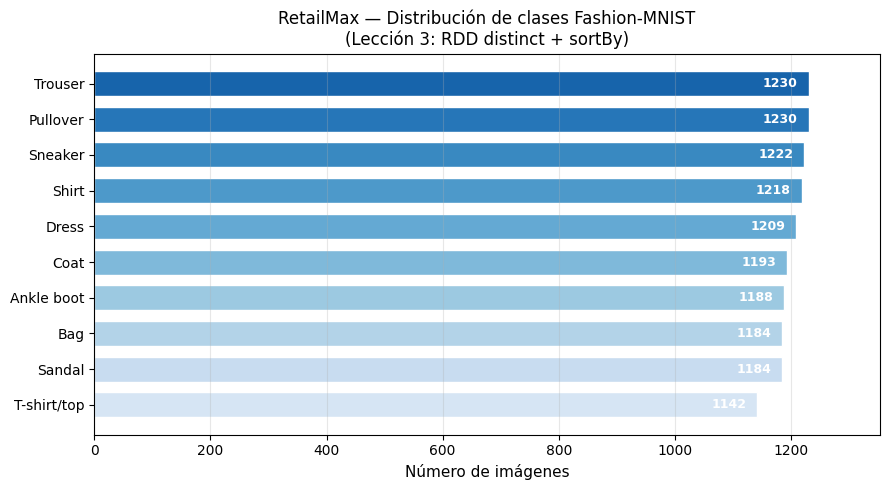

✓ Gráfico guardado: output/output_leccion3_clases.png


In [52]:
# ─── Paso 4.4 — Visualización: bar chart horizontal ────────────────────────
import matplotlib
matplotlib.use("Agg")    # backend sin ventana gráfica (compatible con Jupyter)
import matplotlib.pyplot as plt
%matplotlib inline

clases_graf  = [c[0] for c in conteos]    # etiquetas del eje Y
conteos_graf = [c[1] for c in conteos]    # valores del eje X

fig, ax = plt.subplots(figsize=(9, 5))

# Paleta de colores gradiente por brillo
colores = plt.cm.Blues_r(
    [i / len(conteos_graf) * 0.7 + 0.2 for i in range(len(conteos_graf))]
)

bars = ax.barh(
    clases_graf, conteos_graf,
    color=colores, edgecolor="white", height=0.7
)

# Etiquetas numéricas dentro de cada barra
for bar, val in zip(bars, conteos_graf):
    ax.text(
        bar.get_width() - max(conteos_graf) * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{val}",
        va="center", ha="right",
        color="white", fontsize=9, fontweight="bold"
    )

ax.set_xlabel("Número de imágenes", fontsize=11)
ax.set_title(
    "RetailMax — Distribución de clases Fashion-MNIST\n"
    "(Lección 3: RDD distinct + sortBy)",
    fontsize=12
)
ax.set_xlim(0, max(conteos_graf) * 1.1)
ax.invert_yaxis()    # clase con más registros arriba
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

# Guardar y mostrar
import os
os.makedirs("output", exist_ok=True)
plt.savefig("output/output_leccion3_clases.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Gráfico guardado: output/output_leccion3_clases.png")


---
## Sección 5 — Pair RDDs y `reduceByKey`

### Concepto
Un **Pair RDD** es un RDD cuyos elementos son tuplas `(clave, valor)`.  
Habilita operaciones clave-valor como `reduceByKey`, `groupByKey`, `join`, etc.

```
rdd_base   → map  → RDD de pares:  [("Bag", 0.41), ("Trouser", 0.28), ...]
                                           ↓ reduceByKey
                              [("Bag", suma_total), ("Trouser", suma_total), ...]
```

> **Recordatorio:** usamos `r["pixel_mean"]` — **NO** `r["pixels"]`.


In [53]:
# ─── Paso 5.1 — Crear Pair RDD de (clase, pixel_mean) ───────────────────────
# Clave  = nombre de clase (str)
# Valor  = pixel_mean de esa imagen (float)
# CORRECTO: r["pixel_mean"] — estadística precalculada
# PROHIBIDO: r["pixels"]    — ese campo NO existe en el RDD

rdd_pair_means = rdd_base.map(
    lambda r: (r["label_name"], r["pixel_mean"])
)

print("[5.1] Primeros 5 pares (label_name, pixel_mean):")
for par in rdd_pair_means.take(5):
    print(f"  ('{par[0]}', {par[1]:.6f})")


[5.1] Primeros 5 pares (label_name, pixel_mean):
  ('Ankle boot', 0.381388)
  ('T-shirt/top', 0.423159)
  ('T-shirt/top', 0.143367)
  ('Dress', 0.233338)
  ('T-shirt/top', 0.306057)


In [54]:
# ─── Paso 5.2 — Acumular suma y conteo para calcular media por clase ─────────
# Emitimos (clase, (pixel_mean, 1)) y reducimos sumando elemento a elemento

rdd_pair_sum_count = rdd_base.map(
    lambda r: (r["label_name"], (r["pixel_mean"], 1))
    # valor = (pixel_mean de esta imagen, contador de 1 imagen)
)

rdd_aggregated = rdd_pair_sum_count.reduceByKey(
    lambda a, b: (
        a[0] + b[0],    # sumar pixel_means acumulados
        a[1] + b[1]     # sumar contadores (número de imágenes)
    )
)

print("[5.2] Agregados por clase (suma_pixel_means, count_imágenes) — primeros 3:")
for item in rdd_aggregated.take(3):
    print(f"  '{item[0]}': suma={item[1][0]:.4f}, count={item[1][1]}")


[5.2] Agregados por clase (suma_pixel_means, count_imágenes) — primeros 3:
  'Trouser': suma=276.6580, count=1230
  'T-shirt/top': suma=367.2231, count=1142
  'Dress': suma=310.6924, count=1209


In [55]:
# ─── Paso 5.3 — Calcular media por clase: suma / conteo ──────────────────────

rdd_class_means = (
    rdd_aggregated
    .mapValues(lambda v: round(v[0] / v[1], 6))    # media = suma_means / count_imgs
    .sortBy(lambda x: x[1], ascending=False)        # ordenar de mayor a menor brillo
)

print("[5.3] rdd_class_means creado (aún no ejecutado — lazy)")
print("  Próxima acción collect() desencadenará la ejecución del DAG.")


[5.3] rdd_class_means creado (aún no ejecutado — lazy)
  Próxima acción collect() desencadenará la ejecución del DAG.


In [56]:
# ─── Paso 5.4 — Tabla con barras ASCII de brillo ─────────────────────────────

class_means_list = rdd_class_means.collect()    # acción: ejecutar toda la cadena

print("[5.4] Brillo promedio por clase de ropa (RetailMax):")
print(f"  {'Rank':>4} {'Clase':<14} {'pixel_mean_avg':>14}  Barra de brillo")
print(f"  {'-'*70}")

max_val = max(v for _, v in class_means_list)
for rank, (clase, media) in enumerate(class_means_list, start=1):
    barra_len = int((media / max_val) * 30)            # escalar a 30 caracteres
    barra     = "█" * barra_len + "░" * (30 - barra_len)
    print(f"  {rank:>4} {clase:<14} {media:>14.6f}  {barra}")

clase_brillante  = class_means_list[0][0]
clase_oscura     = class_means_list[-1][0]
print(f"\n  → Clase más brillante : {clase_brillante}")
print(f"  → Clase más oscura    : {clase_oscura}")
print(f"  Interpretación RetailMax: las imágenes de '{clase_brillante}' tienen")
print(f"  mayor brillo promedio — posiblemente fondo blanco o tono claro de prenda.")
print(f"  '{clase_oscura}' tiene las imágenes más oscuras (prendas o fondos oscuros).")


[5.4] Brillo promedio por clase de ropa (RetailMax):
  Rank Clase          pixel_mean_avg  Barra de brillo
  ----------------------------------------------------------------------
     1 Coat                 0.391168  ██████████████████████████████
     2 Pullover             0.378450  █████████████████████████████░
     3 Bag                  0.354367  ███████████████████████████░░░
     4 Shirt                0.334911  █████████████████████████░░░░░
     5 T-shirt/top          0.321561  ████████████████████████░░░░░░
     6 Ankle boot           0.300218  ███████████████████████░░░░░░░
     7 Dress                0.256983  ███████████████████░░░░░░░░░░░
     8 Trouser              0.224925  █████████████████░░░░░░░░░░░░░
     9 Sneaker              0.168469  ████████████░░░░░░░░░░░░░░░░░░
    10 Sandal               0.135459  ██████████░░░░░░░░░░░░░░░░░░░░

  → Clase más brillante : Coat
  → Clase más oscura    : Sandal
  Interpretación RetailMax: las imágenes de 'Coat' tienen
  mayor

---
## Sección 6 — Acciones: `count`, `sum`, `mean`, `stdev`

### Concepto
Las **acciones** desencadenan la ejecución del DAG y devuelven un resultado al driver.  
A diferencia de las transformaciones, **no son lazy** — ejecutan inmediatamente.

| Acción | Devuelve |
|--------|----------|
| `count()` | número de elementos |
| `sum()` | suma de todos los valores (RDD numérico) |
| `mean()` | media aritmética |
| `stdev()` | desviación estándar de la población |
| `max()` / `min()` | valor máximo / mínimo |
| `collect()` | lista Python con todos los elementos |
| `take(n)` | lista Python con los primeros n elementos |


In [57]:
# ─── Paso 6.1 — Crear RDD numérico de pixel_mean ────────────────────────────
# Necesitamos un RDD de sólo floats para usar las acciones estadísticas

rdd_values = rdd_base.map(lambda r: r["pixel_mean"])    # RDD de float32
# ↑ CORRECTO: r["pixel_mean"]
# ✗ INCORRECTO: r["pixels"] → NO existe en este RDD

print("[6.1] RDD de valores numéricos (pixel_mean) creado")
print(f"  Primeros 5 valores: {rdd_values.take(5)}")


[6.1] RDD de valores numéricos (pixel_mean) creado
  Primeros 5 valores: [0.3813875615596771, 0.42315927147865295, 0.14336736500263214, 0.2333383411169052, 0.3060574531555176]


In [58]:
# ─── Paso 6.2 — Ejecutar acciones estadísticas con medición de tiempo ────────
import time

resultados = {}

# count() — número total de elementos
t0 = time.time()
resultados["count"] = rdd_values.count()
resultados["t_count"] = time.time() - t0

# sum() — suma de todos los valores
t0 = time.time()
resultados["sum"] = rdd_values.sum()
resultados["t_sum"] = time.time() - t0

# mean() — media aritmética
t0 = time.time()
resultados["mean"] = rdd_values.mean()
resultados["t_mean"] = time.time() - t0

# stdev() — desviación estándar de la población
t0 = time.time()
resultados["stdev"] = rdd_values.stdev()
resultados["t_stdev"] = time.time() - t0

# max() — valor máximo
t0 = time.time()
resultados["max"] = rdd_values.max()
resultados["t_max"] = time.time() - t0

# min() — valor mínimo
t0 = time.time()
resultados["min"] = rdd_values.min()
resultados["t_min"] = time.time() - t0

print(f"[6.2] Acciones ejecutadas sobre rdd_values (pixel_mean):")
print(f"  {'Acción':<10} {'Resultado':>16}  {'Tiempo':>8}")
print(f"  {'-'*40}")
print(f"  {'count':<10} {int(resultados['count']):>16}  {resultados['t_count']:>7.3f}s")
print(f"  {'sum':<10} {resultados['sum']:>16.4f}  {resultados['t_sum']:>7.3f}s")
print(f"  {'mean':<10} {resultados['mean']:>16.6f}  {resultados['t_mean']:>7.3f}s")
print(f"  {'stdev':<10} {resultados['stdev']:>16.6f}  {resultados['t_stdev']:>7.3f}s")
print(f"  {'max':<10} {resultados['max']:>16.6f}  {resultados['t_max']:>7.3f}s")
print(f"  {'min':<10} {resultados['min']:>16.6f}  {resultados['t_min']:>7.3f}s")


[6.2] Acciones ejecutadas sobre rdd_values (pixel_mean):
  Acción            Resultado    Tiempo
  ----------------------------------------
  count                 12000    3.556s
  sum               3437.1353    3.561s
  mean               0.286428    3.485s
  stdev              0.126239    3.298s
  max                0.725795    3.564s
  min                0.019388    3.720s


In [60]:
# ─── Paso 6.3 — Fórmula de desviación estándar (mini-ejemplo numérico) ──────
# σ = √( Σ(xᵢ - μ)² / N )

muestra = [0.2, 0.4, 0.6, 0.8]
N       = len(muestra)
mu      = sum(muestra) / N                             # media
diffs   = [(x - mu)**2 for x in muestra]               # diferencias al cuadrado
varianza = sum(diffs) / N                              # varianza de la población
desv     = varianza ** 0.5                             # desviación estándar

print("[6.3] Fórmula desviación estándar (σ):")
print(f"  Datos         : {muestra}")
print(f"  N             : {N}")
print(f"  μ (media)     : {mu:.3f}")
print(f"  (xᵢ - μ)²    : {[round(d, 4) for d in diffs]}")
print(f"  σ² (varianza) : Σ(xᵢ-μ)² / N = {sum(diffs):.4f} / {N} = {varianza:.4f}")
print(f"  σ (desv.est.) : √{varianza:.4f} = {desv:.4f}")
print(f"\n  Verificación con Spark rdd:")
desv_spark = sc.parallelize(muestra).stdev()
print(f"  sc.parallelize({muestra}).stdev() = {desv_spark:.4f} ")


[6.3] Fórmula desviación estándar (σ):
  Datos         : [0.2, 0.4, 0.6, 0.8]
  N             : 4
  μ (media)     : 0.500
  (xᵢ - μ)²    : [0.09, 0.01, 0.01, 0.09]
  σ² (varianza) : Σ(xᵢ-μ)² / N = 0.2000 / 4 = 0.0500
  σ (desv.est.) : √0.0500 = 0.2236

  Verificación con Spark rdd:
  sc.parallelize([0.2, 0.4, 0.6, 0.8]).stdev() = 0.2236 


---
## Sección 7 — DAG y Linaje

### Concepto
Spark construye un **DAG** (Directed Acyclic Graph) de transformaciones **lazy**.  
Cada transformación registra su linaje sin ejecutarse.

- **Linaje**: cadena de transformaciones desde el origen hasta el RDD actual.
- **`toDebugString()`**: método que devuelve el linaje en texto legible.
- **Stage**: secuencia de transformaciones narrow entre dos operaciones wide.

```
Stage 0:  parallelize → map → filter → map   (todo narrow)
    ↓  (shuffle boundary por sortBy)
Stage 1:  sortBy                              (wide — nuevo stage)
```


In [61]:
# ─── Paso 7.1 — Construir cadena de transformaciones para visualizar DAG ─────

rdd_final = (
    rdd_base                                        # nivel 0: datos crudos
    .map(lambda r: (r["image_id"], r["label"],
                    r["label_name"], r["split"]))   # nivel 1: metadata (NARROW)
    .filter(lambda r: r[1] == 8)                    # nivel 2: sólo Bags (NARROW)
    .map(lambda r: (r[0], r[2], "Bag detectado"))   # nivel 3: enriquecer (NARROW)
    .sortBy(lambda r: r[0])                         # nivel 4: ordenar (WIDE - shuffle)
)

print("[7.1] Cadena de transformaciones construida (lazy — no ejecutado aún)")
print("  rdd_base → map(metadata) → filter(Bags) → map(enriquecer) → sortBy")


[7.1] Cadena de transformaciones construida (lazy — no ejecutado aún)
  rdd_base → map(metadata) → filter(Bags) → map(enriquecer) → sortBy


In [62]:
# ─── Paso 7.2 — toDebugString(): visualizar el linaje del RDD ───────────────

debug_str = rdd_final.toDebugString().decode("utf-8")    # bytes → str

print("[7.2] toDebugString() — Linaje completo del RDD:")
print("-" * 60)
print(debug_str)
print("-" * 60)


[7.2] toDebugString() — Linaje completo del RDD:
------------------------------------------------------------
(4) PythonRDD[93] at RDD at PythonRDD.scala:58 []
 |  MapPartitionsRDD[92] at mapPartitions at PythonRDD.scala:170 []
 |  ShuffledRDD[91] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(4) PairwiseRDD[90] at sortBy at C:\Users\yuri1\AppData\Local\Temp\ipykernel_25444\1387137986.py:9 []
    |  PythonRDD[89] at sortBy at C:\Users\yuri1\AppData\Local\Temp\ipykernel_25444\1387137986.py:9 []
    |  ParallelCollectionRDD[29] at readRDDFromFile at PythonRDD.scala:299 []
------------------------------------------------------------


In [63]:
# ─── Paso 7.3 — Diagrama ASCII del DAG ──────────────────────────────────────

dag_ascii = """
  ╔═══════════════════════════════════╗
  ║   rdd_base (parallelize)          ║  ← sc.parallelize() — 4 particiones
  ╚══════════════════┬════════════════╝
                     │  NARROW
                     ▼
  ╔═══════════════════════════════════╗
  ║   map(metadata tuple)             ║  ← 1 dict → 1 tupla (4 campos)
  ╚══════════════════┬════════════════╝
                     │  NARROW
                     ▼
  ╔═══════════════════════════════════╗
  ║   filter(label == 8)              ║  ← elimina registros no-Bag
  ╚══════════════════┬════════════════╝
                     │  NARROW
                     ▼
  ╔═══════════════════════════════════╗
  ║   map(enriquecer)                 ║  ← añade texto 'Bag detectado'
  ╚══════════════════┬════════════════╝
                     │  WIDE (shuffle) ← Stage boundary
                     ▼
  ╔═══════════════════════════════════╗
  ║   sortBy(image_id)                ║  ← redistribuye datos entre nodos
  ╚═══════════════════════════════════╝
"""
print("[7.3] Diagrama ASCII del DAG de rdd_final:")
print(dag_ascii)


[7.3] Diagrama ASCII del DAG de rdd_final:

  ╔═══════════════════════════════════╗
  ║   rdd_base (parallelize)          ║  ← sc.parallelize() — 4 particiones
  ╚══════════════════┬════════════════╝
                     │  NARROW
                     ▼
  ╔═══════════════════════════════════╗
  ║   map(metadata tuple)             ║  ← 1 dict → 1 tupla (4 campos)
  ╚══════════════════┬════════════════╝
                     │  NARROW
                     ▼
  ╔═══════════════════════════════════╗
  ║   filter(label == 8)              ║  ← elimina registros no-Bag
  ╚══════════════════┬════════════════╝
                     │  NARROW
                     ▼
  ╔═══════════════════════════════════╗
  ║   map(enriquecer)                 ║  ← añade texto 'Bag detectado'
  ╚══════════════════┬════════════════╝
                     │  WIDE (shuffle) ← Stage boundary
                     ▼
  ╔═══════════════════════════════════╗
  ║   sortBy(image_id)                ║  ← redistribuye datos entre n

In [64]:
# ─── Paso 7.4 — Narrow vs Wide transformations ──────────────────────────────

print("[7.4] Narrow vs Wide transformations:")
print()
print("  NARROW (sin shuffle):")
print("    • map, filter, flatMap, mapValues, mapPartitions")
print("    • Cada partición de salida depende de UNA sola partición de entrada")
print("    • Rápidas: no mueven datos entre nodos")
print("    • Se ejecutan en el mismo Stage")
print("    • Ejemplo correcto: rdd_base.map(lambda r: r['pixel_mean'])")
print()
print("  WIDE (con shuffle):")
print("    • reduceByKey, groupByKey, sortBy, join, distinct")
print("    • Cada partición de salida puede necesitar datos de MÚLTIPLES particiones")
print("    • Más lentas: implican I/O de red y escritura en disco (shuffle)")
print("    • Spark crea un nuevo Stage por cada wide transformation")
print()
print("  Regla práctica RetailMax: minimizar wide transformations")
print("  en pipelines de procesamiento de catálogo en tiempo real.")


[7.4] Narrow vs Wide transformations:

  NARROW (sin shuffle):
    • map, filter, flatMap, mapValues, mapPartitions
    • Cada partición de salida depende de UNA sola partición de entrada
    • Rápidas: no mueven datos entre nodos
    • Se ejecutan en el mismo Stage
    • Ejemplo correcto: rdd_base.map(lambda r: r['pixel_mean'])

  WIDE (con shuffle):
    • reduceByKey, groupByKey, sortBy, join, distinct
    • Cada partición de salida puede necesitar datos de MÚLTIPLES particiones
    • Más lentas: implican I/O de red y escritura en disco (shuffle)
    • Spark crea un nuevo Stage por cada wide transformation

  Regla práctica RetailMax: minimizar wide transformations
  en pipelines de procesamiento de catálogo en tiempo real.


---
## Sección 8 — `cache()` y Persistencia

### Concepto
`cache()` (equivalente a `persist(MEMORY_AND_DISK)`) guarda el RDD en memoria  
para reutilizarlo sin recomputarlo desde cero.

```
Sin cache: cada acción recorre toda la cadena desde rdd_base
   count() → rdd_base → filter → count()
   count() → rdd_base → filter → count()  ← vuelve a recalcular

Con cache: la primera acción almacena el resultado
   count() → rdd_base → filter → [CACHÉ] → count()
   count() →                    [CACHÉ] → count()  ← lee desde memoria
```

> Útil cuando el mismo RDD se usa en múltiples acciones o iteraciones  
> (algoritmos de ML iterativos, pipelines de validación, etc.).


In [65]:
# ─── Paso 8.1 — Medir tiempo SIN cache ──────────────────────────────────────
# Cada count() recorre toda la cadena desde rdd_base

rdd_sin_cache = rdd_base.filter(lambda r: r["split"] == "train")

print("[8.1] SIN cache — dos count() consecutivos:")

t0 = time.time()
n1_sc = rdd_sin_cache.count()    # 1ª ejecución: recorre rdd_base desde cero
t1_sc = time.time() - t0
print(f"  count() #1 = {n1_sc}  →  {t1_sc:.3f}s  (computa desde rdd_base)")

t0 = time.time()
n2_sc = rdd_sin_cache.count()    # 2ª ejecución: VUELVE a recorrer rdd_base
t2_sc = time.time() - t0
print(f"  count() #2 = {n2_sc}  →  {t2_sc:.3f}s  (vuelve a computar desde cero)")


[8.1] SIN cache — dos count() consecutivos:
  count() #1 = 10000  →  3.412s  (computa desde rdd_base)
  count() #2 = 10000  →  3.334s  (vuelve a computar desde cero)


In [66]:
# ─── Paso 8.2 — Medir tiempo CON cache() ────────────────────────────────────

rdd_con_cache = rdd_base.filter(lambda r: r["split"] == "train").cache()
#                                                                   ↑ persist(MEMORY_AND_DISK)

print("[8.2] CON cache() — dos count() consecutivos:")

t0 = time.time()
n1_cc = rdd_con_cache.count()    # 1ª ejecución: computa + guarda en caché
t1_cc = time.time() - t0
print(f"  count() #1 = {n1_cc}  →  {t1_cc:.3f}s  (computa + guarda en caché)")

t0 = time.time()
n2_cc = rdd_con_cache.count()    # 2ª ejecución: lee directamente desde caché
t2_cc = time.time() - t0
print(f"  count() #2 = {n2_cc}  →  {t2_cc:.3f}s  (lee desde caché — sin recomputar)")


[8.2] CON cache() — dos count() consecutivos:
  count() #1 = 10000  →  6.627s  (computa + guarda en caché)
  count() #2 = 10000  →  3.361s  (lee desde caché — sin recomputar)


In [70]:
# ─── Paso 8.3 — Comparativa y conclusiones ───────────────────────────────────

print("[8.3] Comparativa sin cache vs con cache:")
print(f"  {'Escenario':<20} {'1ra ejecución':>14}  {'2da ejecución':>14}")
print(f"  {'-'*54}")
print(f"  {'Sin cache':<20} {t1_sc:>13.3f}s  {t2_sc:>13.3f}s")
print(f"  {'Con cache':<20} {t1_cc:>13.3f}s  {t2_cc:>13.3f}s")

# Calcular mejora (cuidado con división por cero)
if t2_cc > 0:
    mejora = t2_sc / t2_cc
    print(f"\n  Mejora en 2da ejecución: {mejora:.1f}x más rápido con caché")

print("\n  Cuándo usar cache():")
print("    SI-- RDD usado en múltiples acciones (count + sum + mean = 3 acciones)")
print("    SI-- Algoritmos iterativos de ML (k-means, regresión logística)")
print("    NO-- RDD de un sólo uso (cache no compensa el overhead de persistencia)")

# Liberar caché explícitamente para no consumir memoria innecesariamente
rdd_con_cache.unpersist()
print("\n    Caché liberada con unpersist() — buena práctica en producción")


[8.3] Comparativa sin cache vs con cache:
  Escenario             1ra ejecución   2da ejecución
  ------------------------------------------------------
  Sin cache                    3.412s          3.334s
  Con cache                    6.627s          3.361s

  Mejora en 2da ejecución: 1.0x más rápido con caché

  Cuándo usar cache():
    SI-- RDD usado en múltiples acciones (count + sum + mean = 3 acciones)
    SI-- Algoritmos iterativos de ML (k-means, regresión logística)
    NO-- RDD de un sólo uso (cache no compensa el overhead de persistencia)

    Caché liberada con unpersist() — buena práctica en producción


---
## Sección 9 — Guardar resultados a disco con `saveAsTextFile`

### Concepto
`saveAsTextFile(path)` es una **acción** que escribe cada elemento del RDD  
como una línea de texto en el directorio especificado.  
Spark crea un archivo `part-XXXXX` por partición.

```
rdd.coalesce(1).saveAsTextFile("output/") →     output/part-00000
rdd con 4 particiones.saveAsTextFile("out/") →  output/part-00000
                                                output/part-00001
                                                output/part-00002
                                                output/part-00003
```


In [71]:
# ─── Paso 9.1 — Preparar RDD ligero en formato CSV ──────────────────────────
import shutil, os

RUTA_OUTPUT = "output/leccion3_muestra"    # directorio destino

# Crear RDD de strings CSV (sólo los campos más relevantes)
rdd_csv = rdd_base.map(
    lambda r: (
        f"{r['image_id']},"          # image_id
        f"{r['label']},"             # label numérico
        f"{r['label_name']},"        # nombre de clase
        f"{r['split']},"             # train o test
        f"{r['pixel_mean']:.6f},"    # pixel_mean con 6 decimales
        f"{r['pixel_std']:.6f}"      # pixel_std con 6 decimales
        # ↑ CORRECTO: campos precalculados
        # ✗ PROHIBIDO: r['pixels'] NO EXISTE
    )
)

print(f"[9.1] RDD CSV preparado")
print(f"  Ejemplo de línea: {rdd_csv.first()}")


[9.1] RDD CSV preparado
  Ejemplo de línea: 0,9,Ankle boot,train,0.381388,0.399186


In [72]:
# ─── Paso 9.2 — Limpiar directorio previo si existe ─────────────────────────

if os.path.exists(RUTA_OUTPUT):
    shutil.rmtree(RUTA_OUTPUT)    # eliminar directorio y todo su contenido
    print(f"  Directorio previo eliminado: {RUTA_OUTPUT}")

os.makedirs("output", exist_ok=True)    # crear carpeta 'output' si no existe
print(f"  Directorio 'output' listo")


  Directorio previo eliminado: output/leccion3_muestra
  Directorio 'output' listo


In [73]:
# ─── Paso 9.3 — Guardar como texto con 1 sola partición ─────────────────────
# coalesce(1): fusionar todas las particiones en 1 antes de guardar
# Resultado: un único archivo part-00000 (más fácil de leer después)

rdd_csv.coalesce(1).saveAsTextFile(RUTA_OUTPUT)    # acción: escribe al disco

print(f"[9.3] Datos guardados en: {RUTA_OUTPUT}/")

# Listar archivos generados
archivos = os.listdir(RUTA_OUTPUT)
for arch in sorted(archivos):
    tam = os.path.getsize(os.path.join(RUTA_OUTPUT, arch))
    print(f"  {arch} ({tam:,} bytes)")


[9.3] Datos guardados en: output/leccion3_muestra/
  ._SUCCESS.crc (8 bytes)
  .part-00000.crc (3,620 bytes)
  _SUCCESS (0 bytes)
  part-00000 (461,899 bytes)


In [74]:
# ─── Paso 9.4 — Agregar cabecera CSV manualmente ────────────────────────────
# Spark NO añade headers automáticamente → lo hacemos con Python nativo

part_path = os.path.join(RUTA_OUTPUT, "part-00000")    # único archivo de datos
header    = "image_id,label,label_name,split,pixel_mean,pixel_std"

# Leer contenido existente
with open(part_path, "r", encoding="utf-8") as f:
    contenido = f.read()

# Reescribir con header al inicio
with open(part_path, "w", encoding="utf-8") as f:
    f.write(header + "\n" + contenido)

print(f"[9.4] Header CSV añadido: '{header}'")


[9.4] Header CSV añadido: 'image_id,label,label_name,split,pixel_mean,pixel_std'


In [75]:
# ─── Paso 9.5 — Verificar archivo guardado ──────────────────────────────────

print(f"[9.5] Primeras 6 líneas del archivo guardado:")
print(f"  {'-'*60}")
with open(part_path, "r", encoding="utf-8") as f:
    for i, linea in enumerate(f):
        if i >= 6:
            break
        print(f"  {linea.rstrip()}")
print(f"  {'-'*60}")

# Contar líneas totales (incluyendo header)
with open(part_path, "r", encoding="utf-8") as f:
    n_lineas = sum(1 for _ in f)
print(f"\n  Total líneas (header + datos): {n_lineas}")
print(f"  Total registros de datos     : {n_lineas - 1}")


[9.5] Primeras 6 líneas del archivo guardado:
  ------------------------------------------------------------
  image_id,label,label_name,split,pixel_mean,pixel_std
  0,9,Ankle boot,train,0.381388,0.399186
  1,0,T-shirt/top,train,0.423159,0.395417
  2,0,T-shirt/top,train,0.143367,0.194897
  3,3,Dress,train,0.233338,0.254311
  4,0,T-shirt/top,train,0.306057,0.407228
  ------------------------------------------------------------

  Total líneas (header + datos): 12001
  Total registros de datos     : 12000


---
## Sección 10 — Informe Final y Cierre

### Resumen de operaciones vistas en la Lección 3


In [76]:
# ─── Informe final — Tabla resumen de operaciones ───────────────────────────

resumen = [
    # (Operación, Tipo, Lazy, Para qué sirve en RetailMax)
    ("map",          "Narrow",       "Sí",  "Enriquecer registros: calcular brightness_score"),
    ("filter",       "Narrow",       "Sí",  "Segmentar catálogo: sólo Bags, sólo split=test"),
    ("flatMap",      "Narrow",       "Sí",  "Explotar stats: 1 imagen → 4 tuplas"),
    ("distinct",     "Wide",         "Sí",  "Obtener las 10 clases únicas de producto"),
    ("sortBy",       "Wide",         "Sí",  "Ranking de categorías por brillo promedio"),
    ("reduceByKey",  "Wide",         "Sí",  "Agregar pixel_mean por categoría de ropa"),
    ("mapValues",    "Narrow",       "Sí",  "Dividir suma/conteo en Pair RDD"),
    ("count",        "Acción",       "No",  "Contar imágenes por clase/split"),
    ("sum/mean/stdev","Acción",      "No",  "Estadísticas globales de brillo"),
    ("collect",      "Acción",       "No",  "Traer resultados al driver para graficar"),
    ("saveAsTextFile","Acción",      "No",  "Exportar resultados a disco/S3"),
    ("cache",        "Persistencia", "N/A", "Acelerar pipelines iterativos de ML"),
]

print("Tabla resumen de operaciones — Lección 3 RDD:")
print(f"  {'Operación':<18} {'Tipo':<12} {'Lazy':>5}  {'Para qué sirve en RetailMax'}")
print(f"  {'='*80}")
for op, tipo, lazy, uso in resumen:
    print(f"  {op:<18} {tipo:<12} {lazy:>5}  {uso}")


Tabla resumen de operaciones — Lección 3 RDD:
  Operación          Tipo          Lazy  Para qué sirve en RetailMax
  map                Narrow          Sí  Enriquecer registros: calcular brightness_score
  filter             Narrow          Sí  Segmentar catálogo: sólo Bags, sólo split=test
  flatMap            Narrow          Sí  Explotar stats: 1 imagen → 4 tuplas
  distinct           Wide            Sí  Obtener las 10 clases únicas de producto
  sortBy             Wide            Sí  Ranking de categorías por brillo promedio
  reduceByKey        Wide            Sí  Agregar pixel_mean por categoría de ropa
  mapValues          Narrow          Sí  Dividir suma/conteo en Pair RDD
  count              Acción          No  Contar imágenes por clase/split
  sum/mean/stdev     Acción          No  Estadísticas globales de brillo
  collect            Acción          No  Traer resultados al driver para graficar
  saveAsTextFile     Acción          No  Exportar resultados a disco/S3
  cache    

---
### Próxima Lección — Lección 4: DataFrames y Spark SQL

En la Lección 4 pasaremos de RDDs de bajo nivel a **DataFrames**:  

| Característica | RDD (L3) | DataFrame (L4) |
|----------------|----------|----------------|
| Schema | Sin tipado | Tipado y validado |
| Optimización | Manual | Catalyst Optimizer |
| API | Lambdas Python | SQL + columnar |
| Rendimiento | Base | Mejor (Tungsten) |
| Interoperabilidad | Limitada | Parquet, Delta, CSV |

El RDD base de esta lección se convierte en DataFrame con:
```python
df = spark.createDataFrame(rdd_base)
df.show(5)
df.printSchema()
spark.sql("SELECT label_name, AVG(pixel_mean) FROM catalog GROUP BY label_name")
```

---
### Checklist de Entregables

- [x] Sección 0 — SparkSession + carga datos (TF/PT/sklearn/sintéticos)
- [x] Sección 1 — `map`: metadata, brightness_score, normalización [-1,1]
- [x] Sección 2 — `filter`: Bags, imágenes brillantes, split test
- [x] Sección 3 — `flatMap`: 1 imagen → 4 tuplas estadísticas
- [x] Sección 4 — `distinct` + `sortBy` + bar chart horizontal matplotlib
- [x] Sección 5 — Pair RDDs + `reduceByKey` + tabla de brillo por clase
- [x] Sección 6 — Acciones: `count`, `sum`, `mean`, `stdev`, `max`, `min`
- [x] Sección 7 — DAG `toDebugString` + diagrama ASCII narrow vs wide
- [x] Sección 8 — `cache()`: comparativa de tiempos sin/con caché
- [x] Sección 9 — `saveAsTextFile` + header CSV manual
- [x] Sección 10 — Informe final + conexión Lección 4


In [78]:
# ─── Cerrar SparkSession ─────────────────────────────────────────────────────
# Siempre cerrar al finalizar para liberar recursos (memoria, puertos, threads)

print("Cerrando SparkSession...")
spark.stop()
print("  SparkSession cerrada correctamente")
print("  Lección 3 completada — Retail Analytics Pipeline · Módulo 9")
print("  Próxima lección: DataFrames y Spark SQL")


Cerrando SparkSession...
  SparkSession cerrada correctamente
  Lección 3 completada — Retail Analytics Pipeline · Módulo 9
  Próxima lección: DataFrames y Spark SQL
